> Mostly follows priyam's code

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

from torchvision import transforms
from torchvision.datasets import MNIST
from torch.utils.data import DataLoader

import os, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE


import torch.optim as optim
from tqdm import tqdm
from matplotlib.animation import FuncAnimation




/Users/kay/miniconda/envs/diy/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
transform = transforms.Compose(
    [
        transforms.Resize((32,32)), 
        transforms.ToTensor()
    ]
)

train_set = MNIST("../data/mnist/", train=True, transform=transform)
test_set = MNIST("../data/mnist/", train=False, transform=transform)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

### Conv auto-encoder

In [3]:
for img, label in train_set:
    print(img, label)
    break

tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]]) 5


In [4]:
batch_size = 4
train = DataLoader(train_set, batch_size=batch_size, shuffle=True)
val = DataLoader(test_set, batch_size=batch_size, shuffle=False)

for x, y in train:
    print(x.shape, y.shape)
    break

torch.Size([4, 1, 32, 32]) torch.Size([4])


In [5]:
class LinearAutoEncoder(nn.Module):
    def __init__(self, bottleneck = 2):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(32*32, 128),
            nn.ReLU(),
            nn.Linear(128, 64), 
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, bottleneck)
        )

        self.decoder = nn.Sequential(
            nn.Linear(bottleneck, 32),
            nn.ReLU(),
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, 32*32),
            nn.Sigmoid()
        )

    def forward_enc(self, x):
        return self.encoder(x)

    def forward_dec(self, x):
        x = self.decoder(x)
        return x.reshape(-1,1,32,32)
    
    def forward(self, x):
        x = x.flatten(1)
        enc = self.encoder(x)
        dec = self.decoder(enc)
        return enc, dec

model = LinearAutoEncoder( ) 
for x, y in train:
    enc, dec = model(x)
    print(x.shape, enc.shape, dec.shape)
    break
model

torch.Size([4, 1, 32, 32]) torch.Size([4, 2]) torch.Size([4, 1024])


LinearAutoEncoder(
  (encoder): Sequential(
    (0): Linear(in_features=1024, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): ReLU()
    (6): Linear(in_features=32, out_features=2, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=2, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=128, bias=True)
    (5): ReLU()
    (6): Linear(in_features=128, out_features=1024, bias=True)
    (7): Sigmoid()
  )
)

In [6]:
class ConvAutoEncoder(nn.Module):
    def __init__(self, in_channels = 1, bottleneck = 2):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d( in_channels=in_channels, out_channels= 8, kernel_size=3, stride=2, padding=1, bias=False ),
            nn.BatchNorm2d(8),
            nn.ReLU(),

            nn.Conv2d( in_channels=8, out_channels= 16, kernel_size=3, padding=1, stride=2, bias=False ),
            nn.BatchNorm2d(16),
            nn.ReLU(),

            nn.Conv2d( in_channels=16, out_channels= bottleneck, kernel_size=3, padding=1, stride=2),

        )

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d( in_channels = bottleneck, out_channels=16, kernel_size=3, padding=1, stride=2, output_padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),

            nn.ConvTranspose2d( in_channels = 16, out_channels=8, kernel_size=3, padding=1, stride=2, output_padding=1),
            nn.BatchNorm2d(8),
            nn.ReLU(),

            nn.ConvTranspose2d( in_channels = 8, out_channels=in_channels, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid(),
        )

    def forward_enc(self, x):
        return self.encoder(x)

    def forward_dec(self, x):
        return self.decoder(x)
    
    def forward(self, x):
        enc = self.encoder(x)
        dec = self.decoder(enc)
        return enc, dec


model = ConvAutoEncoder( ) 
for x, y in train:
    enc, dec = model(x)
    print(x.shape, enc.shape, dec.shape)
    break
model

torch.Size([4, 1, 32, 32]) torch.Size([4, 2, 4, 4]) torch.Size([4, 1, 32, 32])


ConvAutoEncoder(
  (encoder): Sequential(
    (0): Conv2d(1, 8, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (1): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(8, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): Conv2d(16, 2, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  )
  (decoder): Sequential(
    (0): ConvTranspose2d(2, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): ConvTranspose2d(16, 8, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (4): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): ConvTranspose2d(8, 1, kernel_size=(3, 3), str

In [12]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ConvAutoEncoder().to(DEVICE)
ln_model = ConvAutoEncoder().to(DEVICE)
optm = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

In [14]:
def train_model(max_steps, eval_iter, model, train_data_loader, val_data_loader, optm, loss_fn):
    logs = {
        "step" : [],
        "training_loss": [],
        "val_loss": [],
    }
    continue_train = True
    train_loss, eval_loss, step_counter = [], [], 0
    encoded_evals = []
    pbar = tqdm(range(max_steps))

    while continue_train:
        for x, labels in train_data_loader:
            step_counter += 1

            x = x.to(DEVICE)
            enc, dec = model(x)
            loss = loss_fn(dec, x)
            optm.zero_grad()
            loss.backward()
            optm.step()
            train_loss.append(loss.item())

            if step_counter % eval_iter == 0:
                logs["training_loss"].append(np.mean(train_loss))
                logs["step"].append(step_counter)
                encoded_data = []

                with torch.no_grad():
                    for x, labels in val_data_loader:
                        x = x.to(DEVICE)
                        enc, dec = model(x)
                        loss = criterion(dec, x)
                        eval_loss.append(loss.item())

                        enc, labels = enc.cpu().flatten(1), labels.reshape(-1,1)
                        encoded_data.append(torch.cat((enc, labels), axis=-1))
                
                encoded_evals.append(torch.concatenate(encoded_data))
                logs["val_loss"].append(np.mean(eval_loss))

                train_loss, eval_loss = [], []

                print(
                    f"Step {step_counter}/ {max_steps} | "
                    f"Train Loss: {logs['training_loss'][-1]:.4f} | Val Loss: {logs['val_loss'][-1]:.4f} "
                )

            pbar.update(1)
            if step_counter >= max_steps:
                print("Training completed")
                continue_train = False
                break
        
    return model, logs, encoded_evals
trained_model, logs, encoded_evals = train_model(model=ln_model, max_steps=25000, eval_iter=250,
                    train_data_loader=train, val_data_loader=val, optm=optm, loss_fn=criterion)

  1%|          | 276/25000 [00:07<26:25, 15.59it/s] 

Step 250/ 25000 | Train Loss: 0.2699 | Val Loss: 0.2702 


  2%|▏         | 519/25000 [00:14<29:53, 13.65it/s] 

Step 500/ 25000 | Train Loss: 0.2704 | Val Loss: 0.2702 


  3%|▎         | 747/25000 [00:15<02:35, 156.23it/s]

KeyboardInterrupt: 

  3%|▎         | 749/25000 [00:30<02:35, 156.23it/s]

In [19]:
encoded_evals[0].shape

torch.Size([10000, 33])

In [37]:
from matplotlib.animation import FuncAnimation, PillowWriter

# Prepare figure
fig, ax = plt.subplots(figsize=(8, 6))

def update(frame_idx):
    ax.clear()
    encoded = encoded_evals[frame_idx].numpy()
    features = encoded[:, :-1]
    labels = encoded[:, -1]

    sns.scatterplot(
        x=features[:, 0],
        y=features[:, 1],
        hue=labels,
        palette="tab10",
        s=10,
        alpha=0.7,
        legend=True,
        ax=ax
    )
    ax.set_title(f"2D Latent Space - Step {frame_idx+1}/{len(encoded_evals)}")
    ax.set_xlabel("Latent Dim 1")
    ax.set_ylabel("Latent Dim 2")

# Create animation
anim = FuncAnimation(fig, update, frames=len(encoded_evals), interval=500, repeat=True)

# Save as GIF
anim.save("latent_space_evolution.gif", writer=PillowWriter(fps=2))

plt.close(fig)  # Close the static figure
print("Saved latent_space_evolution.gif ✅")


Saved latent_space_evolution.gif ✅


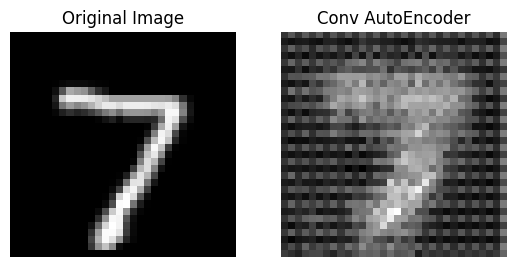

In [39]:
generated_index = 0
image, label = test_set[generated_index]

_, conv_reconstructed = model(image.unsqueeze(0).to(DEVICE))

conv_reconstructed = conv_reconstructed.to("cpu").detach().numpy()

fig, ax = plt.subplots(1,2)

ax[0].imshow(image.squeeze(), cmap="gray")
ax[0].set_title("Original Image")
ax[0].set_xticklabels([])
ax[0].set_yticklabels([])
ax[0].axis("off")

ax[1].imshow(conv_reconstructed.squeeze(), cmap="gray")
ax[1].set_title("Conv AutoEncoder")
ax[1].set_xticklabels([])
ax[1].set_yticklabels([])
ax[1].axis("off")


plt.show()


### pre-trained